#Practical Simulation – Day 2
Again we will simulate genomic data from two populations of Anopheles gambiae from different locations. We have 41 diploid samples from GN and 99 diploid samples for BF. We wish to compare and isolation only with an Isolation-with-Migration (IM) model and estimate their demographic history.

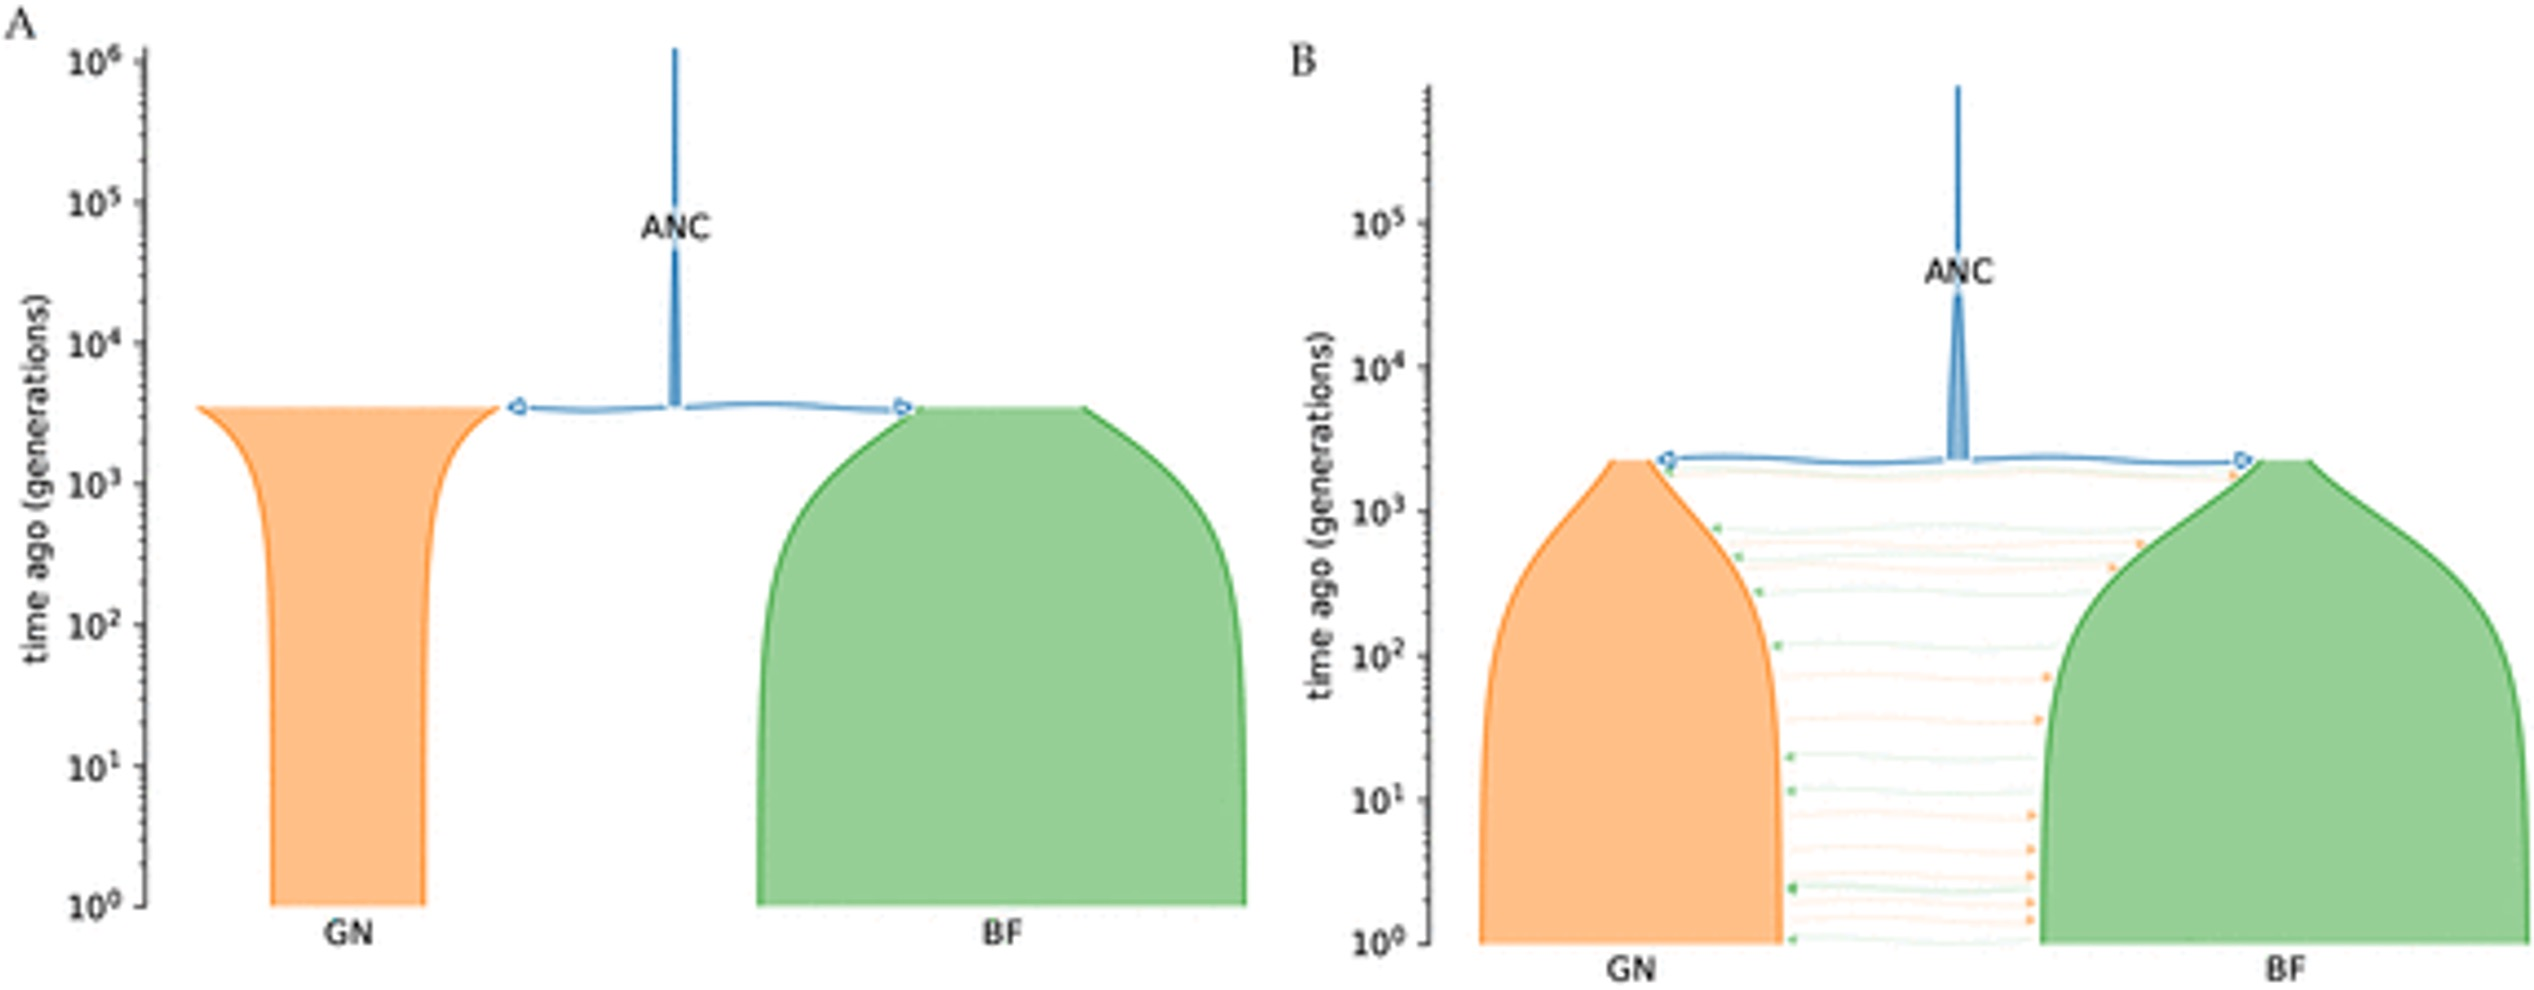

In [1]:
# 1. Install everything silently
!pip install -q msprime tskit demes demesdraw

# 2. Force a path refresh
import site
from importlib import reload
reload(site)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 32.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 39.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 kB 1.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.1/118.1 kB 4.3 MB/s eta 0:00:00


<module 'site' (frozen)>

In [2]:
# Task: decide on prior distributions and generate simulations
import os
import csv
import msprime
import demesdraw
import matplotlib.pyplot as plt
import tskit
import numpy as np
import pandas as pd

In [3]:
# Define some initial parameters (fixed defaults)
k = 10 #scaling parameter to make simulations faster
params = {
    "N1": 750_000 / k,    # Population 1 (GN) size
    "N2": 1_500_000 / k,     # Population 2 (BF) size
    "T_split": 3_000 / k,    # Time of population split
    "N_anc": 500_000 / k,   # Ancestral population size (500,000)
    "mut": 3.5e-9 * k,      # Mutation rate, fixed
    "length": 150_000,      # Sequence length, fixed. THis is the size of windows we use in the genome.
    "reco": 1.45e-8 * k,     # recombination rate, fixed
    "mig": 0.1            # migration rate, fixed
}

In [4]:
# Define additional parameters
sample_sizes = [41, 99]  # Sample sizes for two populations (41 in GN and 99 in BF)
seed = None               # Random seed

In [5]:
# Function for simulating data under an isolation model with parameters:
# Nanc, T_split, N1, N2

def no_mig(params, sample_sizes, seed, reco, target_snps=250):
# Initialize the demography object
    demog = msprime.Demography()

    # 1. Define the populations (Current)
    demog.add_population(name="GN", initial_size=params["N1"])
    demog.add_population(name="BF", initial_size=params["N2"])

    # 2. Define the ancestral population
    demog.add_population(name="Anc", initial_size=params["N_anc"])

    # 3. Define the split (Backward: merge GN and BF into Anc)
    # This replaces MassMigration. It handles the 'proportion=1.0' automatically.
    demog.add_population_split(time=params["T_split"], derived=["GN", "BF"], ancestral="Anc")

    # 4. Simulate Ancestry
    # Note: sample_sizes should be 112 for GN and 112 for BF (total 224 haplotypes)
    ts = msprime.sim_ancestry(
        samples={"GN": sample_sizes[0], "BF": sample_sizes[1]},
        demography=demog,
        sequence_length=params["length"],
        recombination_rate=params["reco"],
        random_seed=params.get("seed")
    )

    # 5. Add Mutations
    mts = msprime.sim_mutations(ts, rate=params["mut"])


    # 2. Check if we have enough SNPs
    if mts.num_sites < target_snps:
        # If not enough, re-simulate with longer length or skip
        return None

    # 3. Extract exactly the first 'target_snps'
    # Get genotypes: shape (num_sites, total_samples)
    genotypes = mts.genotype_matrix()[:target_snps, :]

    # Get positions: shape (num_sites,)
    positions = [s.position for s in mts.sites()][:target_snps]

    return demog, genotypes, np.array(positions)


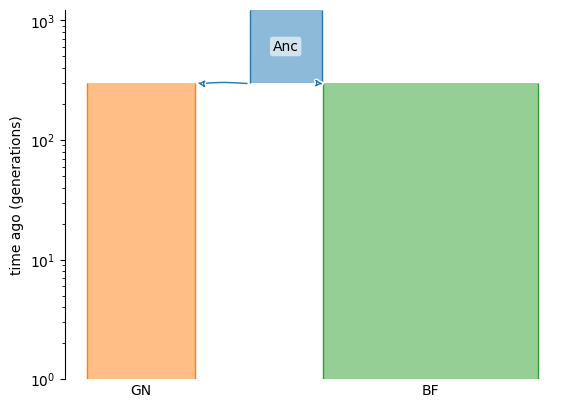

In [ ]:
demog, genotypes, positions = no_mig(params, sample_sizes, seed, params["reco"])

# Plot a schematic of the model
demesdraw.tubes(demog.to_demes(), ax=plt.gca(), seed=1, log_time=True)
plt.show()

In [ ]:
genotypes.shape

(250, 280)

In [ ]:
positions.shape

(250,)

In [6]:
# Function for simulating data under an isolation with migration model with parameters:
# Nanc, T_split, N1, N2, mig

def im(params, sample_sizes, seed, reco, target_snps=250):
# Initialize the demography object
    demog = msprime.Demography()

    # 1. Define the populations
    demog.add_population(name="GN", initial_size=params["N1"])
    demog.add_population(name="BF", initial_size=params["N2"])
    demog.add_population(name="Anc", initial_size=params["N_anc"])

# 2. Add Continuous Migration
    # Note: 'rate' is the fraction of the population replaced by migrants each generation.
    # Backward-in-time: source="BF", dest="GN" means BF individuals move to GN.
    # This represents FORWARD gene flow from GN into BF.
    mig_rate = params.get("mig", 0.1)

    if mig_rate != 0:
        # Forward GN -> BF (Backward BF -> GN)
        demog.set_migration_rate(source="BF", dest="GN", rate=abs(mig_rate))
        # Forward BF -> GN (Backward GN -> BF)
        demog.set_migration_rate(source="GN", dest="BF", rate=abs(mig_rate))

    # 3. Define the split (Backward: merge GN and BF into Anc)
    # This replaces MassMigration. It handles the 'proportion=1.0' automatically.
    demog.add_population_split(time=params["T_split"], derived=["GN", "BF"], ancestral="Anc")

    # 4. Simulate Ancestry
    # Note: sample_sizes should be 112 for GN and 112 for BF (total 224 haplotypes)
    ts = msprime.sim_ancestry(
        samples={"GN": sample_sizes[0], "BF": sample_sizes[1]},
        demography=demog,
        sequence_length=params["length"],
        recombination_rate=params["reco"],
        random_seed=params.get("seed")
    )

    # 5. Add Mutations
    mts = msprime.sim_mutations(ts, rate=params["mut"])

    # 2. Check if we have enough SNPs
    if mts.num_sites < target_snps:
        # If not enough, re-simulate with longer length or skip
        return None

    # 3. Extract exactly the first 'target_snps'
    # Get genotypes: shape (num_sites, total_samples)
    genotypes = mts.genotype_matrix()[:target_snps, :]

    # Get positions: shape (num_sites,)
    positions = [s.position for s in mts.sites()][:target_snps]

    return demog, genotypes, np.array(positions)

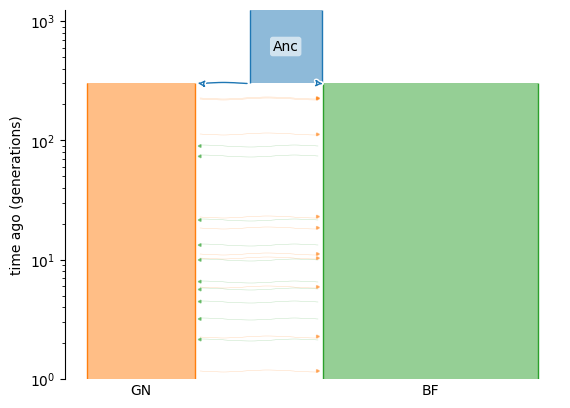

In [ ]:
demog, ts = im(params, sample_sizes, seed, params["reco"])

# Plot a schematic of the model
demesdraw.tubes(demog.to_demes(), ax=plt.gca(), seed=1, log_time=True)
plt.show()

## Task 1: simulate data for Deep Learning (CNN)

In [7]:
# Output directory
output_directory = "."
# Output file name
output_file = os.path.join(output_directory, "mosquito-task2_no_mig.csv")

In [8]:
# Open the output file in write mode
with open(output_file, "w", newline="") as csvfile:
    writer = csv.writer(csvfile, delimiter=",")

    # Write header
    writer.writerow(["N1", "N2", "T_split", "mig"])

    # 1. Initialize an empty list before the loop
    all_simulations = []
    # Perform simulations
    for i in range(10): # We are performing only 10 simulations as they take very long to complete.

        params["N1"] = 750_000 / k
        params["N2"] = 1_500_000 / k
        params["mig"] = 0
        params["T_split"] = np.random.randint(low=2_000 / k, high=4_000 / k, size=1)[0]

        demog, gt, pos = no_mig(params, sample_sizes, seed, params["reco"])

        # Create the 2nd channel: Log-Distances
        dist = np.diff(pos, append=pos[-1] + 1)
        log_dist = np.log1p(dist)
        # Tile distances to match the width of the haplotype matrix
        dist_channel = np.tile(log_dist[:, np.newaxis], (1, gt.shape[1]))

        # Final CNN Input: (500, 280, 2)
        sims_nomig = np.stack([gt, dist_channel], axis=-1)
        all_simulations.append(sims_nomig)

        # Write data to file or print data
        writer.writerow([params["N1"], params["N2"], params["T_split"], params["mig"]])

# Convert the list into a 4D NumPy array (The "Tensor")
# This creates the shape: (nsims, 500, 280, 2)
sims_nomig = np.array(all_simulations)
# Save the tensor for your CNN
np.save("sims_nomig.npy", sims_nomig)


In [ ]:
sims_nomig.shape

(1000, 250, 280, 2)

In [14]:
# Output directory
output_directory = "."
# Output file name
output_file = os.path.join(output_directory, "mosquito-task2_im.csv")

In [15]:
# Open the output file in write mode
with open(output_file, "w", newline="") as csvfile:
    writer = csv.writer(csvfile, delimiter=",")

    # Write header
    writer.writerow(["N1", "N2", "T_split", "mig"])

    # 1. Initialize an empty list before the loop
    all_simulations = []
    # Perform simulations
    for i in range(100): # We are performing only 10 simulations as they take very long to complete.

        params["N1"] = 750_000 / k
        params["N2"] = 1_500_000 / k
        params["mig"] = 0.1
        params["T_split"] = np.random.randint(low=2_000 / k, high=4_000 / k, size=1)[0]

        demog, gt, pos = im(params, sample_sizes, seed, params["reco"])

        # Create the 2nd channel: Log-Distances
        dist = np.diff(pos, append=pos[-1] + 1)
        log_dist = np.log1p(dist)
        # Tile distances to match the width of the haplotype matrix
        dist_channel = np.tile(log_dist[:, np.newaxis], (1, gt.shape[1]))

        # Final CNN Input: (500, 280, 2)
        sims_im = np.stack([gt, dist_channel], axis=-1)
        all_simulations.append(sims_im)

        # Write data to file or print data
        writer.writerow([params["N1"], params["N2"], params["T_split"], params["mig"]])

# Convert the list into a 4D NumPy array (The "Tensor")
# This creates the shape: (nsims, 500, 280, 2)
sims_im = np.array(all_simulations)
# Save the tensor for your CNN
np.save("sims_im.npy", sims_im)

In [16]:
sims_im.shape

(100, 250, 280, 2)